In [40]:
import xsimlab as xs
import vmlab
import pandas as pd
import matplotlib.pyplot as plt
from importlib import resources
from vmlab.models import arch_dev_model # Usamos el modelo base sugerido

importamos core

In [41]:
# --- 1. Importar los procesos que queremos añadir ---
import vmlab.processes.phenology as phenology
import vmlab.processes.environment as environment
from vmlab.processes.harvest import Harvest
# --- 1. Crear nuestro modelo de diagnóstico ---
# Empezamos con el modelo de desarrollo de arquitectura que YA funciona
# y simplemente eliminamos los procesos que no son parte de este núcleo.
# Es probable que 'geometry' y 'appearance' no estén, pero los eliminamos
# por si acaso, para asegurar una prueba mínima.
diagnostic_model = arch_dev_model
diagnostic_model = diagnostic_model.update_processes({
    'phenology': phenology.Phenology, 
    'environment': environment.Environment,
    'harvest': Harvest
})

print("--- Modelo de Diagnóstico Creado ---")

--- Modelo de Diagnóstico Creado ---


In [ ]:
# --- 2. Cargar el árbol inicial (requerido por Topology) ---
with resources.path('vmlab.data.trees', 'tree_B10_cycle_030405.csv') as path:
    initial_tree = pd.read_csv(path)

In [46]:
# --- 3. Configurar la simulación ---
# (Esta sección es idéntica a la anterior)
setup = vmlab.create_setup(
    model=diagnostic_model,
    tree=initial_tree,
    start_date='2003-06-01',
    end_date='2004-06-01', 
    setup_toml='vmango_fosil.toml', 
    input_vars={},
    output_vars={
        'topology': {
            'appearance_date': 'day',
            'appearance_month':'day',
            'appeared':'day',               
            'cycle': None,
            'adjacency' : None,
            'is_apical' : None
        },
        'phenology':{
            'flowered':'day',
            'leaf_growth_tts': 'day'
        },
        'arch_dev': {
            'pot_flowering_date' : 'day',
            'pot_nb_fruit': 'day'
        },
        'environment': {'TM_day': 'day'}
    }
)

In [47]:
# --- 4. Ejecutar el modelo de diagnóstico ---
print("Ejecutando prueba de acoplamiento (Método Corregido)...")
ds_out = vmlab.run(setup, diagnostic_model, geometry=False)
print("Prueba completada.")

Ejecutando prueba de acoplamiento (Método Corregido)...


             0% | initialize 

Prueba completada.


c:\Users\jcarlos.vargas\AppData\Local\anaconda3\envs\vmango-lab\lib\site-packages\xarray\core\utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


C:\Users\jcarlos.vargas\AppData\Local\Temp\ipykernel_20896\940170993.py:24: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from current font.
  fig.tight_layout(rect=[0, 0.03, 1, 0.95])
C:\Users\jcarlos.vargas\AppData\Local\Temp\ipykernel_20896\940170993.py:24: UserWarning: Glyph 127810 (\N{FALLEN LEAF}) missing from current font.
  fig.tight_layout(rect=[0, 0.03, 1, 0.95])
c:\Users\jcarlos.vargas\AppData\Local\anaconda3\envs\vmango-lab\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jcarlos.vargas\AppData\Local\anaconda3\envs\vmango-lab\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127810 (\N{FALLEN LEAF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


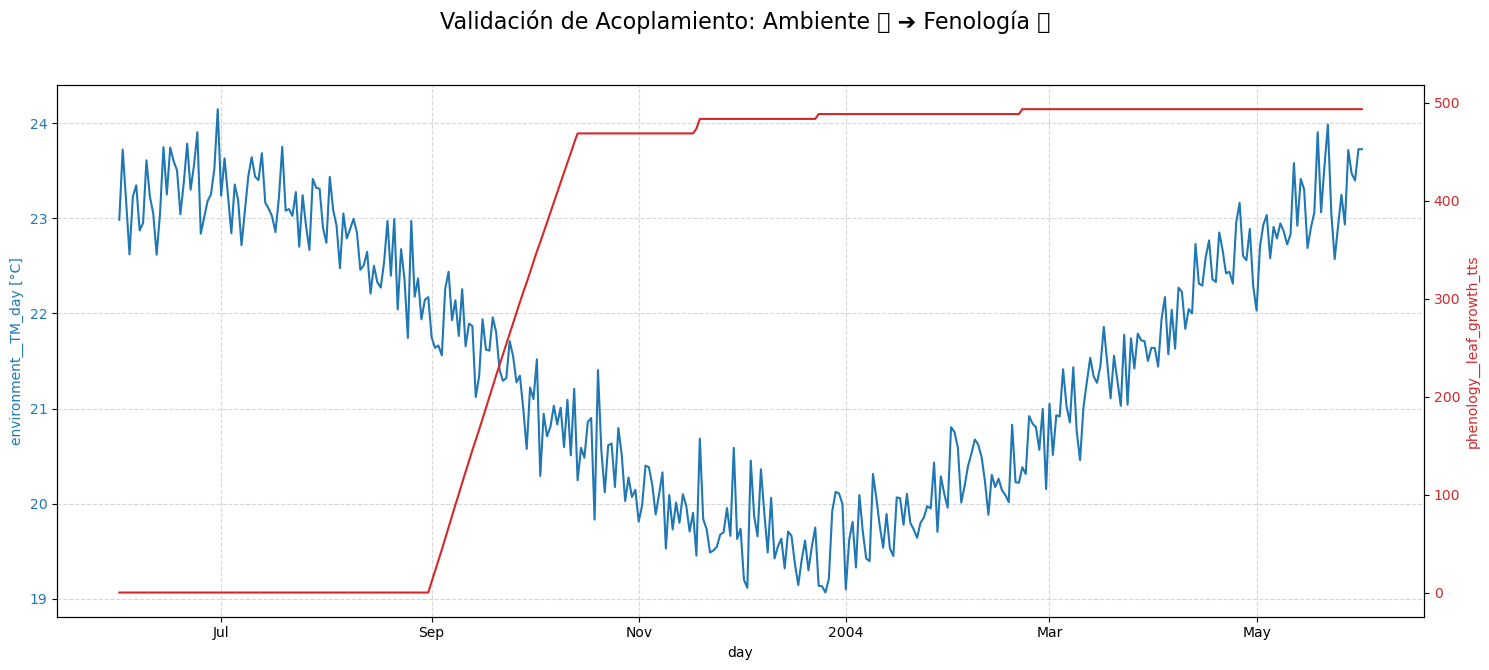

In [51]:
# --- 6. Visualizar los resultados ---
fig, ax1 = plt.subplots(figsize=(15, 7))

color = 'tab:blue'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Temperatura Media Diaria (°C)', color=color)
ds_out.environment__TM_day.plot(ax=ax1, color=color, label='Temp. (Paleoclima)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Acumulación MÁXIMA de TTS (grados-día)', color=color)

# --- CAMBIO CLAVE AQUÍ ---
# En lugar de .isel(GU=0), usamos .max(dim='GU')
# Esto grafica la yema más activa del árbol, no el tronco.
ds_out.phenology__leaf_growth_tts.max(dim='GU').plot(ax=ax2, color=color, label='TTS Hoja (Máx. en cualquier GU)')
# -------------------------

ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('Validación de Acoplamiento: Ambiente 🌡️ ➔ Fenología 🍂', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

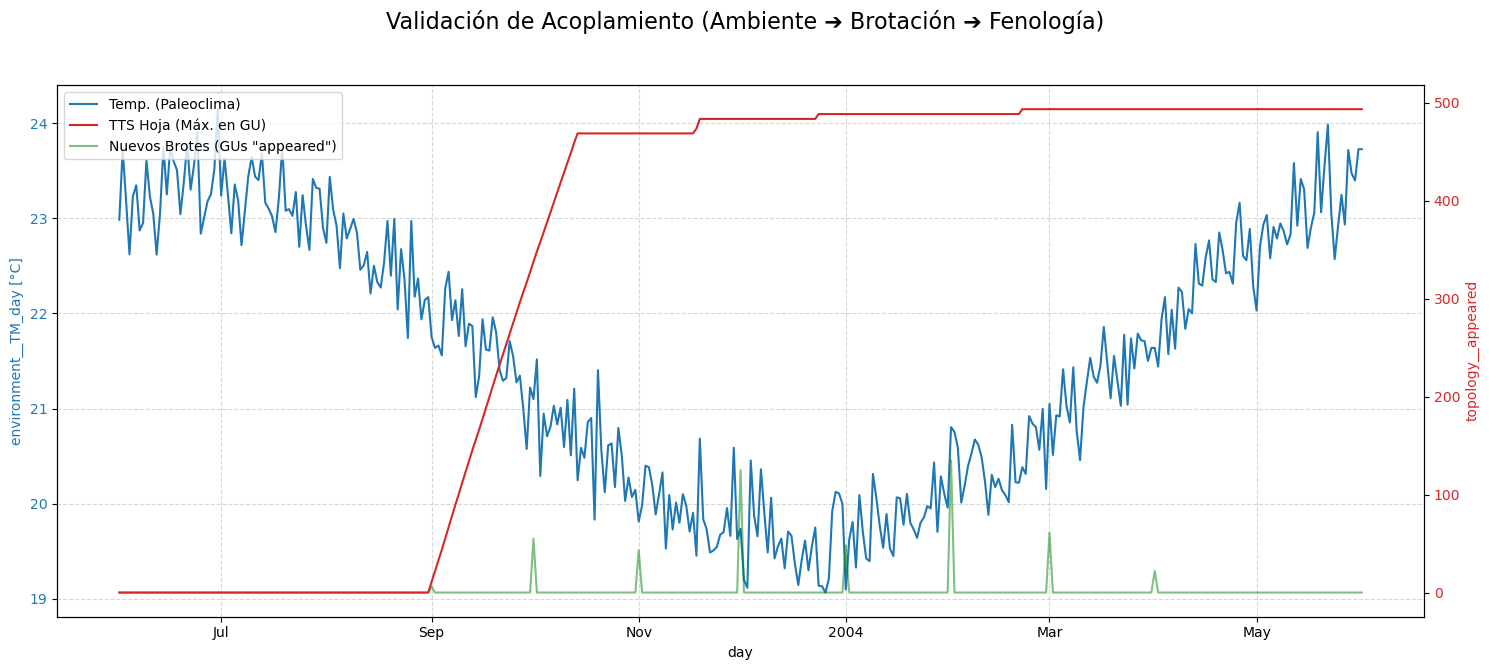

In [56]:
# --- 6. Visualizar los resultados (CORREGIDO) ---
fig, ax1 = plt.subplots(figsize=(15, 7))

# --- Eje 1: Temperatura (Línea Azul) ---
color = 'tab:blue'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Temperatura Media Diaria (°C)', color=color)
ds_out.environment__TM_day.plot(ax=ax1, color=color, label='Temp. (Paleoclima)', zorder=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Eje 2: Acumulación de TTS (Línea Roja) ---
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Acumulación MÁXIMA de TTS (grados-día)', color=color)
ds_out.phenology__leaf_growth_tts.max(dim='GU').plot(ax=ax2, color=color, label='TTS Hoja (Máx. en GU)', zorder=3)
ax2.tick_params(axis='y', labelcolor=color)

# --- Eje 3: El "Interruptor" (Barras Verdes) - CORREGIDO ---
# Contar cuántas GUs "aparecieron" cada día
brotes_diarios = ds_out.topology__appeared.sum(dim='GU')

# Usamos .plot.bar() de xarray para que maneje las coordenadas automáticamente
brotes_diarios.plot.line(ax=ax2, color='green', alpha=0.5, 
                        label='Nuevos Brotes (GUs "appeared")', zorder=1)

# --- Añadir leyendas ---
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

fig.suptitle('Validación de Acoplamiento (Ambiente ➔ Brotación ➔ Fenología)', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()